In [5]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# 1.
def replace_hate_with_love(s):
    return re.sub(r'hate', 'love', s, flags=re.IGNORECASE)

s = "HaTe HATE hate"
print("1. feladat:")
print(replace_hate_with_love(s))

1. feladat:
love love love


In [20]:
# 2.
contains_the = lambda s: 'the' in s.lower()

s1 = "aaaaaaaaatheaaaaaaaa"
s2 = "aaaabbbbbbcccctha"

print("\n2. feladat:")
print(f"'{s1}' tartalmazza 'the' szót? {contains_the(s1)}")
print(f"'{s2}' tartalmazza 'the' szót? {contains_the(s2)}")


2. feladat:
'aaaaaaaaatheaaaaaaaa' tartalmazza 'the' szót? True
'aaaabbbbbbcccctha' tartalmazza 'the' szót? False


In [7]:
# 3.
file_path = "vending_machine.csv"
df = pd.read_csv(file_path)
print(df.head())

   ID               Item  Price  Stock  Sold_Units  Calories  Sugar_g
0   1  Vodka Baby Bottle   10.0    0.0          50        97      0.0
1   2               Coke    3.5   50.0         120       140     39.0
2   3              Water    2.0   30.0         250         0      0.0
3   4     Chips (Salted)    4.2   25.0          80       160      0.5
4   5      Chocolate Bar    5.0   10.0          40       220     24.0


In [9]:
# 4.
print("\n4. infok:")
df.info()

print("\n4. Statisztikak:")
print(df.describe())


4. infok:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          29 non-null     int64  
 1   Item        29 non-null     object 
 2   Price       29 non-null     float64
 3   Stock       26 non-null     float64
 4   Sold_Units  29 non-null     int64  
 5   Calories    29 non-null     int64  
 6   Sugar_g     29 non-null     float64
dtypes: float64(3), int64(3), object(1)
memory usage: 1.7+ KB

4. Statisztikak:
              ID      Price      Stock  Sold_Units    Calories    Sugar_g
count  29.000000  29.000000  26.000000   29.000000   29.000000  29.000000
mean   15.000000   4.046552  33.192308   85.517241  140.931034  13.293103
std     8.514693   1.855105  22.533565   62.861878   95.594729  15.593907
min     1.000000   1.200000   0.000000   15.000000    0.000000   0.000000
25%     8.000000   2.800000  16.500000   40.000000   97.000000   0.0

In [10]:
# 5.
null_counts = df.isnull().sum()
total_nulls = null_counts.sum()

print("\n5. feladat:")
print(null_counts)
print(f"Összes null érték: {total_nulls}")


5. feladat:
ID            0
Item          0
Price         0
Stock         3
Sold_Units    0
Calories      0
Sugar_g       0
dtype: int64
Összes null érték: 3


In [ ]:
# 6.
df['Stock'] = df['Stock'].fillna(0)
df['Stock'] = df['Stock'].astype(int)

print("\n6. feladat:")
df.info()


6. Adatkeret info (nullérték feltöltése és típuskonverzió után):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          29 non-null     int64  
 1   Item        29 non-null     object 
 2   Price       29 non-null     float64
 3   Stock       29 non-null     int64  
 4   Sold_Units  29 non-null     int64  
 5   Calories    29 non-null     int64  
 6   Sugar_g     29 non-null     float64
dtypes: float64(2), int64(4), object(1)
memory usage: 1.7+ KB


In [12]:
# 7.
output_file = "vending_clean.csv"
df.to_csv(output_file, index=False)

In [14]:
# 8.
df['Revenue'] = df['Price'] * df['Sold_Units']

print("\n8. feladat:")
print(df[['Item', 'Revenue']].sort_values(by='Revenue', ascending=False).head())


8. feladat:
                 Item  Revenue
5        Energy Drink    975.0
9         Soda (Diet)    630.0
0   Vodka Baby Bottle    500.0
2               Water    500.0
15           Iced Tea    494.0



9. Top 5 bevételi diagram elkészült.


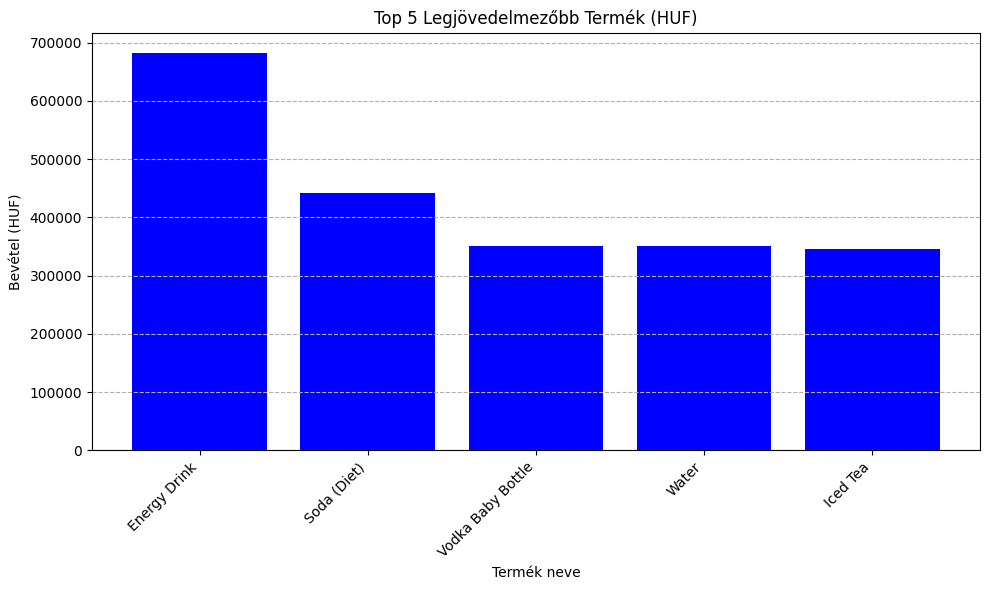

In [ ]:
# 9.
df['Revenue_HUF'] = df['Revenue'] * 700
top_5_revenue = df.sort_values(by='Revenue_HUF', ascending=False).head(5)

plt.figure(figsize=(10, 6))
plt.bar(top_5_revenue['Item'], top_5_revenue['Revenue_HUF'], color='blue')

plt.title('Top 5 Legjövedelmezőbb Termék (HUF)')
plt.xlabel('Termék neve')
plt.ylabel('Bevétel')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()

In [ ]:
# 10.
df_clean = df[df['Stock'] > 0].copy()

print("\n10. feladat:")
print(f"Eredeti sorok száma: {len(df)}")
print(f"Készleten lévő sorok száma: {len(df_clean)}")
print("Készleten lévő termékek (head):")
print(df_clean.head())


10. Elfogyott termékek eltávolítása (Stock > 0):
Eredeti sorok száma: 29
Készleten lévő sorok száma: 25
Készleten lévő termékek (head):
   ID            Item  Price  Stock  Sold_Units  Calories  Sugar_g  \
1   2            Coke    3.5     50         120       140     39.0   
2   3           Water    2.0     30         250         0      0.0   
3   4  Chips (Salted)    4.2     25          80       160      0.5   
4   5   Chocolate Bar    5.0     10          40       220     24.0   
5   6    Energy Drink    6.5     60         150       210     54.0   

   Revenue_EUR  Revenue_HUF  Revenue  
1        420.0     294000.0    420.0  
2        500.0     350000.0    500.0  
3        336.0     235200.0    336.0  
4        200.0     140000.0    200.0  
5        975.0     682500.0    975.0  
